In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Veriyi yükle
iris = load_iris()
X = iris.data        # 150 örnek, 4 özellik
y = iris.target      # 0, 1, 2 — 3 çiçek türü

print("Veri shape:", X.shape)
print("Etiket shape:", y.shape)
print("\nÖzellikler:", iris.feature_names)
print("Sınıflar:", iris.target_names)
print("\nİlk 5 örnek:\n", X[:5])
print("\nEtiketler:", y[:10])

Veri shape: (150, 4)
Etiket shape: (150,)

Özellikler: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Sınıflar: ['setosa' 'versicolor' 'virginica']

İlk 5 örnek:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Etiketler: [0 0 0 0 0 0 0 0 0 0]


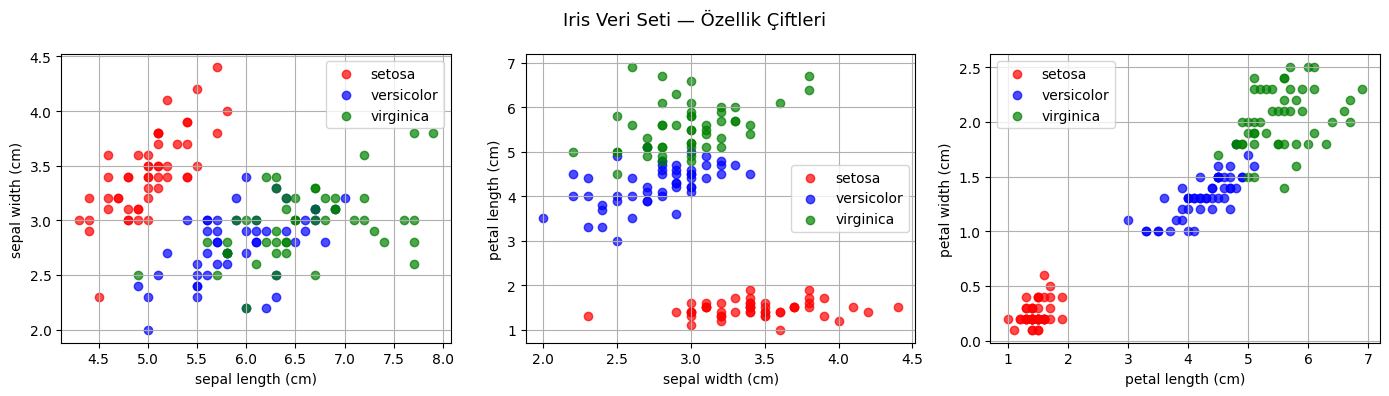

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ['red', 'blue', 'green']
labels = iris.target_names

for i, ax in enumerate(axes):
    for cls in range(3):
        mask = y == cls
        ax.scatter(
            X[mask, i],
            X[mask, i+1],
            c=colors[cls],
            label=labels[cls],
            alpha=0.7
        )
    ax.set_xlabel(iris.feature_names[i])
    ax.set_ylabel(iris.feature_names[i+1])
    ax.legend()
    ax.grid(True)

plt.suptitle("Iris Veri Seti — Özellik Çiftleri", fontsize=13)
plt.tight_layout()
plt.show()

In [3]:
# Train/Test split — %80 eğitim, %20 test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizasyon — Z-score
# Her özelliği ortalaması 0, std'si 1 olacak şekilde ölçekle
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # test'e sadece transform!

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain özellik ortalaması:", X_train.mean(axis=0).round(3))
print("Train özellik std:", X_train.std(axis=0).round(3))

Train shape: (120, 4)
Test shape: (30, 4)

Train özellik ortalaması: [-0. -0.  0.  0.]
Train özellik std: [1. 1. 1. 1.]


In [4]:
from torch.utils.data import TensorDataset, DataLoader

# NumPy → PyTorch tensör
X_train_t = torch.FloatTensor(X_train)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

# Dataset ve DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Train batch sayısı:", len(train_loader))
print("Test batch sayısı:", len(test_loader))

# Bir batch'e bakalım
X_batch, y_batch = next(iter(train_loader))
print("\nBir batch shape:", X_batch.shape)
print("Batch etiketleri:", y_batch)

Train batch sayısı: 8
Test batch sayısı: 2

Bir batch shape: torch.Size([16, 4])
Batch etiketleri: tensor([1, 2, 2, 2, 1, 1, 2, 0, 2, 2, 2, 2, 1, 1, 2, 1])


In [5]:
class IrisNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 16),    # 4 özellik → 16 nöron
            nn.ReLU(),
            nn.Linear(16, 8),   # 16 → 8 nöron
            nn.ReLU(),
            nn.Linear(8, 3)     # 8 → 3 sınıf (çıkışta softmax yok — loss içinde)
        )

    def forward(self, x):
        return self.network(x)

model = IrisNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)
print("\nToplam parametre:", sum(p.numel() for p in model.parameters()))

IrisNet(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)

Toplam parametre: 243


In [6]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0, 0

    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (output.argmax(1) == y_batch).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            output = model(X_batch)
            loss = criterion(output, y_batch)
            total_loss += loss.item()
            correct += (output.argmax(1) == y_batch).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

# Eğitim
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(100):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | Test Loss: {test_loss:.4f} Acc: {test_acc:.2%}")

Epoch   0 | Train Loss: 1.0257 Acc: 52.50% | Test Loss: 0.8926 Acc: 56.67%
Epoch  10 | Train Loss: 0.0727 Acc: 97.50% | Test Loss: 0.0963 Acc: 96.67%
Epoch  20 | Train Loss: 0.0475 Acc: 98.33% | Test Loss: 0.0791 Acc: 96.67%
Epoch  30 | Train Loss: 0.0538 Acc: 97.50% | Test Loss: 0.0727 Acc: 96.67%
Epoch  40 | Train Loss: 0.0432 Acc: 97.50% | Test Loss: 0.0778 Acc: 96.67%
Epoch  50 | Train Loss: 0.0374 Acc: 98.33% | Test Loss: 0.0919 Acc: 96.67%
Epoch  60 | Train Loss: 0.0356 Acc: 97.50% | Test Loss: 0.0964 Acc: 96.67%
Epoch  70 | Train Loss: 0.0276 Acc: 98.33% | Test Loss: 0.1060 Acc: 96.67%
Epoch  80 | Train Loss: 0.0322 Acc: 97.50% | Test Loss: 0.1233 Acc: 96.67%
Epoch  90 | Train Loss: 0.0373 Acc: 99.17% | Test Loss: 0.1400 Acc: 96.67%


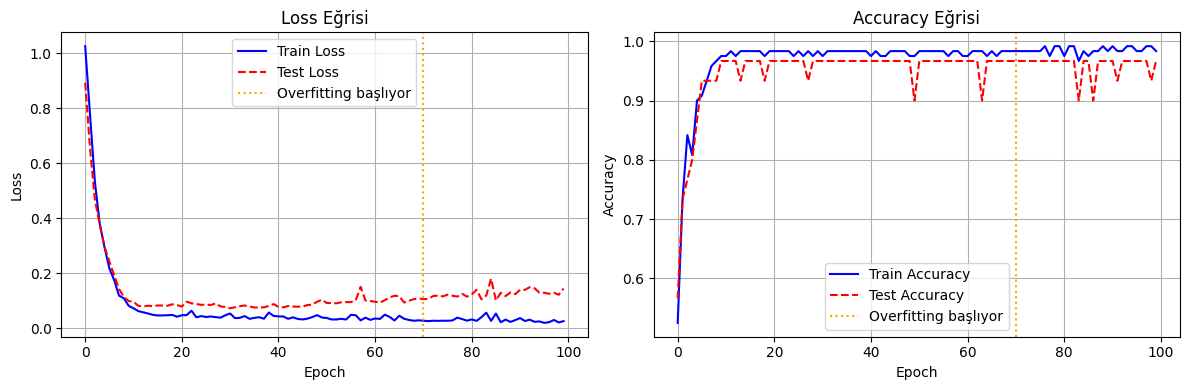

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label='Train Loss', color='blue')
ax1.plot(test_losses, label='Test Loss', color='red', linestyle='--')
ax1.axvline(x=70, color='orange', linestyle=':', label='Overfitting başlıyor')
ax1.set_title("Loss Eğrisi")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='Train Accuracy', color='blue')
ax2.plot(test_accs, label='Test Accuracy', color='red', linestyle='--')
ax2.axvline(x=70, color='orange', linestyle=':', label='Overfitting başlıyor')
ax2.set_title("Accuracy Eğrisi")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [8]:
class IrisNetDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Dropout(0.3),     # %30 nöronu rastgele kapat
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.network(x)

model2 = IrisNetDropout()
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.01)

train_losses2, test_losses2 = [], []
train_accs2, test_accs2 = [], []

for epoch in range(100):
    train_loss, train_acc = train_epoch(model2, train_loader, criterion, optimizer2)
    test_loss, test_acc = evaluate(model2, test_loader, criterion)

    train_losses2.append(train_loss)
    test_losses2.append(test_loss)
    train_accs2.append(train_acc)
    test_accs2.append(test_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | Test Loss: {test_loss:.4f} Acc: {test_acc:.2%}")

Epoch   0 | Train Loss: 0.9690 Acc: 50.00% | Test Loss: 0.8207 Acc: 73.33%
Epoch  10 | Train Loss: 0.3202 Acc: 86.67% | Test Loss: 0.2615 Acc: 90.00%
Epoch  20 | Train Loss: 0.1959 Acc: 93.33% | Test Loss: 0.1563 Acc: 93.33%
Epoch  30 | Train Loss: 0.1317 Acc: 91.67% | Test Loss: 0.1078 Acc: 93.33%
Epoch  40 | Train Loss: 0.1075 Acc: 95.00% | Test Loss: 0.1012 Acc: 96.67%
Epoch  50 | Train Loss: 0.1305 Acc: 95.00% | Test Loss: 0.1030 Acc: 96.67%
Epoch  60 | Train Loss: 0.1164 Acc: 93.33% | Test Loss: 0.0926 Acc: 96.67%
Epoch  70 | Train Loss: 0.1017 Acc: 96.67% | Test Loss: 0.1029 Acc: 96.67%
Epoch  80 | Train Loss: 0.1359 Acc: 94.17% | Test Loss: 0.1001 Acc: 96.67%
Epoch  90 | Train Loss: 0.1048 Acc: 97.50% | Test Loss: 0.0952 Acc: 96.67%


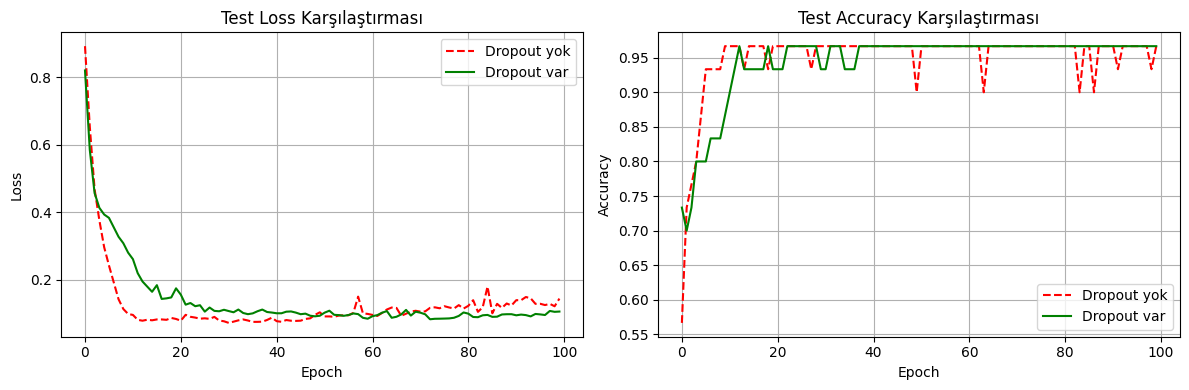

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(test_losses, label='Dropout yok', color='red', linestyle='--')
ax1.plot(test_losses2, label='Dropout var', color='green')
ax1.set_title("Test Loss Karşılaştırması")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(test_accs, label='Dropout yok', color='red', linestyle='--')
ax2.plot(test_accs2, label='Dropout var', color='green')
ax2.set_title("Test Accuracy Karşılaştırması")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()